In [ ]:
#ANN using Fashion MNIST

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 304kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.1MB/s]


In [3]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [4]:
model = ANN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
epochs = 10

for epoch in range(epochs):
    running_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.5144
Epoch [2/10], Loss: 0.3775
Epoch [3/10], Loss: 0.3411
Epoch [4/10], Loss: 0.3159
Epoch [5/10], Loss: 0.3003
Epoch [6/10], Loss: 0.2789
Epoch [7/10], Loss: 0.2706
Epoch [8/10], Loss: 0.2580
Epoch [9/10], Loss: 0.2461
Epoch [10/10], Loss: 0.2390


In [6]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 87.80%


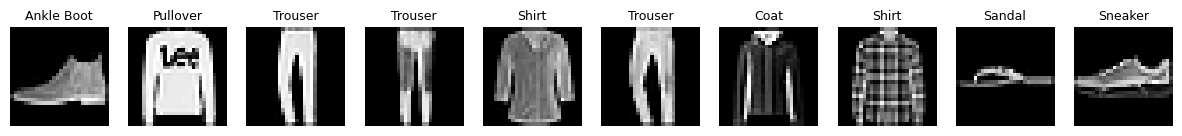

In [9]:
import matplotlib.pyplot as plt
import torch

classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

# Get a batch of test images
images, labels = next(iter(test_loader))

# Get model predictions
outputs = model(images)
_, preds = torch.max(outputs, 1)

# Plot first 10 images
plt.figure(figsize=(15, 4))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"{classes[preds[i]]}", fontsize=9)
    plt.axis('off')

plt.show()

In [ ]:
# Implementation using CNN

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [12]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [13]:
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
epochs = 10

for epoch in range(epochs):
    running_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.4345
Epoch [2/10], Loss: 0.2747
Epoch [3/10], Loss: 0.2284
Epoch [4/10], Loss: 0.1930
Epoch [5/10], Loss: 0.1683
Epoch [6/10], Loss: 0.1449
Epoch [7/10], Loss: 0.1239
Epoch [8/10], Loss: 0.1047
Epoch [9/10], Loss: 0.0852
Epoch [10/10], Loss: 0.0726


In [15]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 92.24%


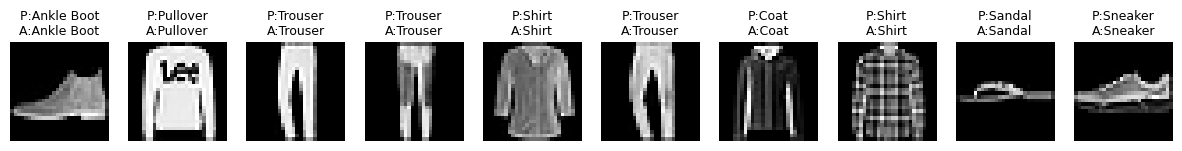

In [16]:
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

images, labels = next(iter(test_loader))
outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"P:{classes[preds[i]]}\nA:{classes[labels[i]]}", fontsize=9)
    plt.axis('off')

plt.show()

In [ ]:
# ANN vs CNN

# ANN has lower accuracy (87.08%) where CNN has higher accuracy (92.24%).